
# Reto: Evaluación del Riesgo Operacional en Canales Electrónicos

Desarrollo basado en el notebook de clase de matrices de riesgo. Se construyen matrices de frecuencia, severidad, pérdidas agregadas, impacto, gestión, pérdida esperada, OpVaR y una herramienta de auditoría para revisar los eventos por celda.


## 0. Carga de librerías

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)


## 1. Carga de la base de datos

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/Integracion de datos y prospectiva/5. Riesgo Operacional FallasTecnológicas.xlsx'

df = pd.read_excel(ruta, sheet_name='Fallas Tecnológicas', header=1)
riesgos = pd.read_excel(ruta, sheet_name='Riesgos', header=1)
gestion = pd.read_excel(ruta, sheet_name='Gestión', header=1)

df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


## 2. Exploración inicial de datos

In [5]:
print('Dimensiones:', df.shape)
print('Columnas:')
print(df.columns)
print('Valores faltantes:')
print(df.isnull().sum())
print('Tipos de datos:')
print(df.dtypes)
print('Estadísticos descriptivos:')
display(df.describe().T)


Dimensiones: (701, 6)
Columnas:
Index(['Fechas', 'Transacciones Diarias', 'Valor Transado (millones)',
       'Transacciones Fallidas', 'Valor Generado Promedio (Millones)',
       'Descripción Evento'],
      dtype='object')
Valores faltantes:
Fechas                                0
Transacciones Diarias                 0
Valor Transado (millones)             0
Transacciones Fallidas                0
Valor Generado Promedio (Millones)    0
Descripción Evento                    0
dtype: int64
Tipos de datos:
Fechas                                datetime64[ns]
Transacciones Diarias                          int64
Valor Transado (millones)                    float64
Transacciones Fallidas                         int64
Valor Generado Promedio (Millones)           float64
Descripción Evento                            object
dtype: object
Estadísticos descriptivos:


,count,mean,min,25%,50%,75%,max,std
Fechas,701,2010-06-25 06:30:17.974322176,2009-01-01 00:00:00,2009-06-25 00:00:00,2011-01-01 00:00:00,2011-06-25 00:00:00,2011-12-17 00:00:00,NaN
Transacciones Diarias,701.0000,99.1583,35.0000,85.0000,100.0000,115.0000,170.0000,22.0811
Valor Transado (millones),701.0000,24.2487,-9.9574,16.8511,24.1620,31.5373,59.5669,11.5987
Transacciones Fallidas,701.0000,4.7532,1.0000,2.0000,4.0000,7.0000,16.0000,2.9848
Valor Generado Promedio (Millones),701.0000,1.9296,0.0842,0.6313,1.2240,2.3439,17.3129,2.1301


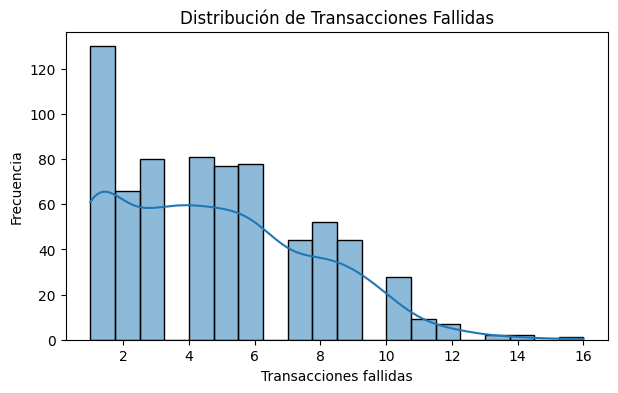

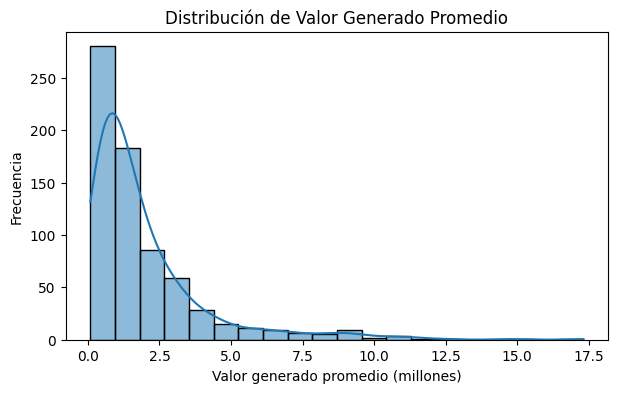

In [6]:
# Visualización inicial de variables clave
plt.figure(figsize=(7,4))
sns.histplot(df['Transacciones Fallidas'], bins=20, kde=True)
plt.title('Distribución de Transacciones Fallidas')
plt.xlabel('Transacciones fallidas')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df['Valor Generado Promedio (Millones)'], bins=20, kde=True)
plt.title('Distribución de Valor Generado Promedio')
plt.xlabel('Valor generado promedio (millones)')
plt.ylabel('Frecuencia')
plt.show()


## 3. Función de clusterización

In [7]:
def clusterizacion(Xi):
    XC = np.random.choice(Xi, size=5)  # 5 clusters
    XC = np.sort(XC)                   # semillas iniciales ordenadas
    nc = np.zeros((len(Xi), 1))         # grupo al que pertenece cada dato

    for k in range(len(Xi)):
        d = np.abs(XC - Xi[k])
        nc[k] = np.argmin(d)
        nc2 = np.int32(nc[k])
        XC[nc2] = (XC[nc2] + Xi[k]) / 2

    return XC, nc


## 4. Variables de frecuencia, severidad y pérdidas agregadas

In [8]:
np.random.seed(42)

# Frecuencia: número de transacciones fallidas
XF = np.array(df['Transacciones Fallidas'])

# Severidad: valor promedio generado por evento, en millones
Xs = np.array(df['Valor Generado Promedio (Millones)'])

# Pérdidas agregadas / LDA: frecuencia x severidad
LDA = XF * Xs

# Clusterización
XCf, ncf = clusterizacion(XF)
XCs, ncs = clusterizacion(Xs)
XClda, nclda = clusterizacion(LDA)

# DataFrame base de matrices
matriz_df = pd.DataFrame({
    'fecha': df['Fechas'],
    'freq': XF,
    'nivel_f': ncf.ravel().astype(int),
    'sev': Xs,
    'nivel_s': ncs.ravel().astype(int),
    'perdida_inherente': LDA,
    'nivel_lda': nclda.ravel().astype(int),
    'descripcion_evento': df['Descripción Evento']
})

matriz_df.head()


,fecha,freq,nivel_f,sev,nivel_s,perdida_inherente,nivel_lda,descripcion_evento
0,2009-01-01,1,0,0.5374,0,0.5374,0,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,4,0,1.1978,2,4.7912,2,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,5,1,0.4269,0,2.1345,1,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,6,1,1.0814,1,6.4884,3,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,7,2,1.2105,2,8.4735,4,"Errores en la interfaz de usuario, fallas en f..."


## 5. Matriz de frecuencia y matriz de severidad

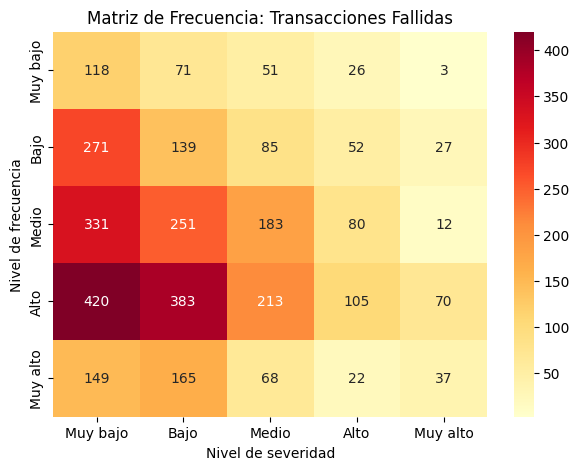

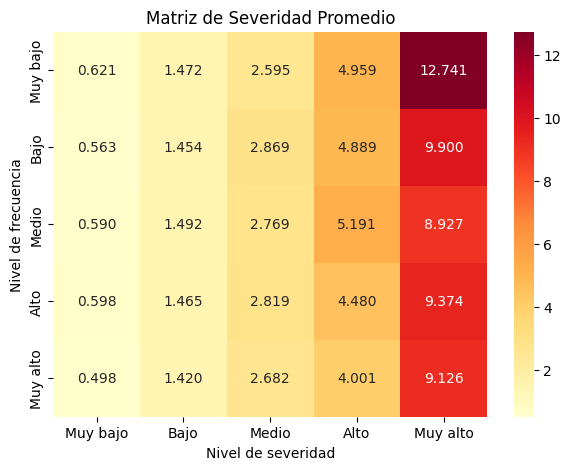

In [9]:
# Matrices 5x5: filas = nivel de frecuencia, columnas = nivel de severidad
MEf = np.zeros((5, 5))  # suma de frecuencias por celda
MEs = np.zeros((5, 5))  # severidad promedio por celda
conteo = np.zeros((5, 5))

for k in range(len(matriz_df)):
    nf = int(matriz_df.loc[k, 'nivel_f'])
    ns = int(matriz_df.loc[k, 'nivel_s'])
    MEf[nf, ns] += matriz_df.loc[k, 'freq']
    MEs[nf, ns] += matriz_df.loc[k, 'sev']
    conteo[nf, ns] += 1

# Evitar divisiones por cero
MEs = np.divide(MEs, conteo, out=np.zeros_like(MEs), where=conteo!=0)

niveles = ['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto']

plt.figure(figsize=(7,5))
sns.heatmap(MEf, annot=True, fmt='.0f', cmap='YlOrRd', xticklabels=niveles, yticklabels=niveles)
plt.title('Matriz de Frecuencia: Transacciones Fallidas')
plt.xlabel('Nivel de severidad')
plt.ylabel('Nivel de frecuencia')
plt.show()

plt.figure(figsize=(7,5))
sns.heatmap(MEs, annot=True, fmt='.3f', cmap='YlOrRd', xticklabels=niveles, yticklabels=niveles)
plt.title('Matriz de Severidad Promedio')
plt.xlabel('Nivel de severidad')
plt.ylabel('Nivel de frecuencia')
plt.show()


## 6. Matriz de pérdidas agregadas

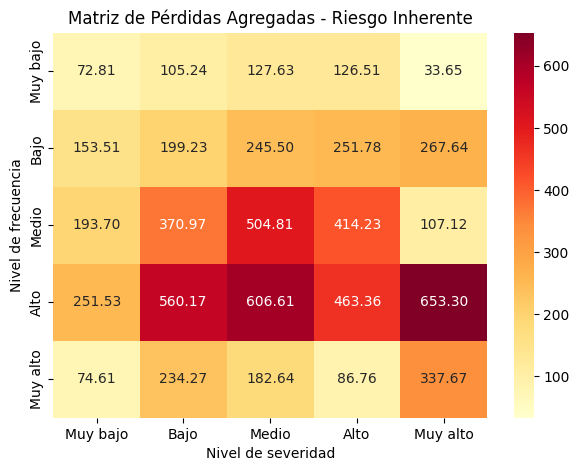

In [10]:
MELDA = np.zeros((5, 5))

for k in range(len(matriz_df)):
    nf = int(matriz_df.loc[k, 'nivel_f'])
    ns = int(matriz_df.loc[k, 'nivel_s'])
    MELDA[nf, ns] += matriz_df.loc[k, 'perdida_inherente']

plt.figure(figsize=(7,5))
sns.heatmap(MELDA, annot=True, fmt='.2f', cmap='YlOrRd', xticklabels=niveles, yticklabels=niveles)
plt.title('Matriz de Pérdidas Agregadas - Riesgo Inherente')
plt.xlabel('Nivel de severidad')
plt.ylabel('Nivel de frecuencia')
plt.show()


## 7. Matriz de impacto y matriz de gestión

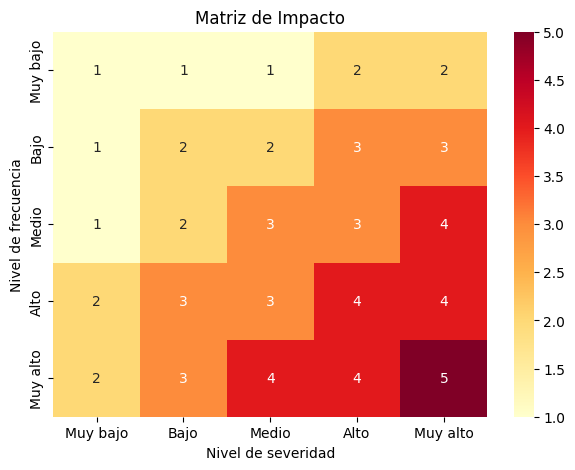

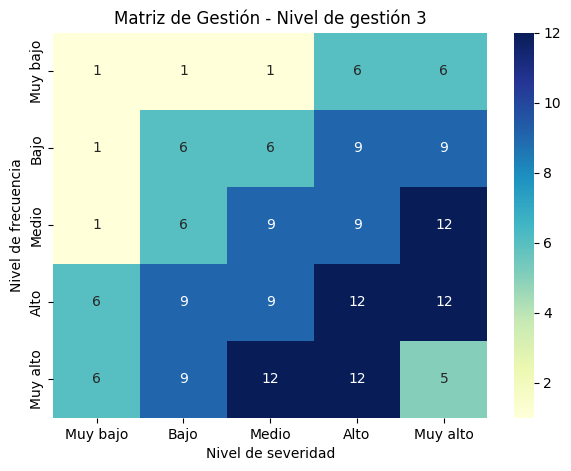

In [12]:
MI = np.array([
    [1, 1, 1, 2, 2],
    [1, 2, 2, 3, 3],
    [1, 2, 3, 3, 4],
    [2, 3, 3, 4, 4],
    [2, 3, 4, 4, 5]
])

plt.figure(figsize=(7,5))
sns.heatmap(MI, annot=True, fmt='.0f', cmap='YlOrRd', xticklabels=niveles, yticklabels=niveles)
plt.title('Matriz de Impacto')
plt.xlabel('Nivel de severidad')
plt.ylabel('Nivel de frecuencia')
plt.show()

# Nivel de gestión seleccionado para el escenario residual.
NG = 3

MG = np.copy(MI).astype(float)
for i in range(5):
    for j in range(5):
        if MG[i, j] > 1 and MG[i, j] < 5:
            MG[i, j] = MG[i, j] * NG

plt.figure(figsize=(7,5))
sns.heatmap(MG, annot=True, fmt='.0f', cmap='YlGnBu', xticklabels=niveles, yticklabels=niveles)
plt.title(f'Matriz de Gestión - Nivel de gestión {NG}')
plt.xlabel('Nivel de severidad')
plt.ylabel('Nivel de frecuencia')
plt.show()


## 8. Riesgo inherente vs riesgo residual

In [13]:
# Asignar impacto y gestión a cada evento según su celda
matriz_df['nivel_impacto'] = matriz_df.apply(lambda row: MI[int(row['nivel_f']), int(row['nivel_s'])], axis=1)
matriz_df['nivel_gestion'] = matriz_df.apply(lambda row: MG[int(row['nivel_f']), int(row['nivel_s'])], axis=1)

# Pérdida no gestionada = riesgo inherente
matriz_df['perdida_no_gestionada'] = matriz_df['perdida_inherente']

# Pérdida gestionada = riesgo residual
# Se reduce la pérdida en función del nivel de gestión asignado.
matriz_df['perdida_gestionada'] = matriz_df['perdida_no_gestionada'] / matriz_df['nivel_gestion']

matriz_df[['fecha', 'freq', 'sev', 'perdida_no_gestionada', 'nivel_impacto', 'nivel_gestion', 'perdida_gestionada', 'descripcion_evento']].head()


,fecha,freq,sev,perdida_no_gestionada,nivel_impacto,nivel_gestion,perdida_gestionada,descripcion_evento
0,2009-01-01,1,0.5374,0.5374,1,1.0000,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,4,1.1978,4.7912,1,1.0000,4.7912,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,5,0.4269,2.1345,1,1.0000,2.1345,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,6,1.0814,6.4884,2,6.0000,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,7,1.2105,8.4735,3,9.0000,0.9415,"Errores en la interfaz de usuario, fallas en f..."


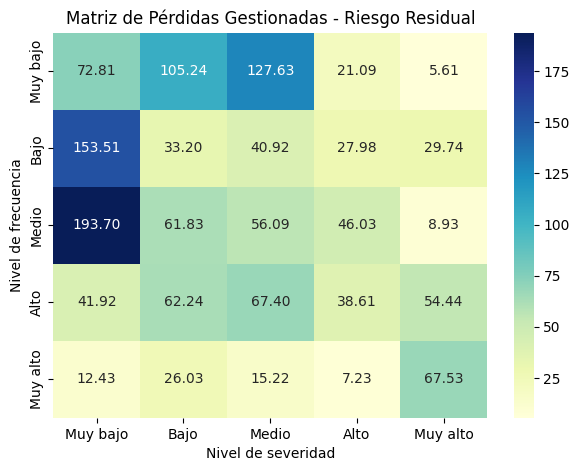

In [14]:
# Matriz de pérdida residual
MER = np.zeros((5, 5))

for k in range(len(matriz_df)):
    nf = int(matriz_df.loc[k, 'nivel_f'])
    ns = int(matriz_df.loc[k, 'nivel_s'])
    MER[nf, ns] += matriz_df.loc[k, 'perdida_gestionada']

plt.figure(figsize=(7,5))
sns.heatmap(MER, annot=True, fmt='.2f', cmap='YlGnBu', xticklabels=niveles, yticklabels=niveles)
plt.title('Matriz de Pérdidas Gestionadas - Riesgo Residual')
plt.xlabel('Nivel de severidad')
plt.ylabel('Nivel de frecuencia')
plt.show()


## 9. Pérdida Esperada y OpVaR 99,9%

In [15]:
# Pérdida esperada: promedio de pérdidas por evento/día
PE_inherente = matriz_df['perdida_no_gestionada'].mean()
PE_residual = matriz_df['perdida_gestionada'].mean()

# OpVaR al 99,9%: percentil 99.9 de las pérdidas
OpVaR_inherente = np.percentile(matriz_df['perdida_no_gestionada'], 99.9)
OpVaR_residual = np.percentile(matriz_df['perdida_gestionada'], 99.9)

resumen_riesgo = pd.DataFrame({
    'Escenario': ['Riesgo inherente / no gestionado', 'Riesgo residual / gestionado'],
    'Pérdida Esperada': [PE_inherente, PE_residual],
    'OpVaR 99.9%': [OpVaR_inherente, OpVaR_residual]
})

resumen_riesgo['Reducción vs inherente PE'] = [0, 1 - (PE_residual / PE_inherente)]
resumen_riesgo['Reducción vs inherente OpVaR'] = [0, 1 - (OpVaR_residual / OpVaR_inherente)]

resumen_riesgo


,Escenario,Pérdida Esperada,OpVaR 99.9%,Reducción vs inherente PE,Reducción vs inherente OpVaR
0,Riesgo inherente / no gestionado,9.4511,102.9021,0.0000,0.0000
1,Riesgo residual / gestionado,1.9648,15.9674,0.7921,0.8448


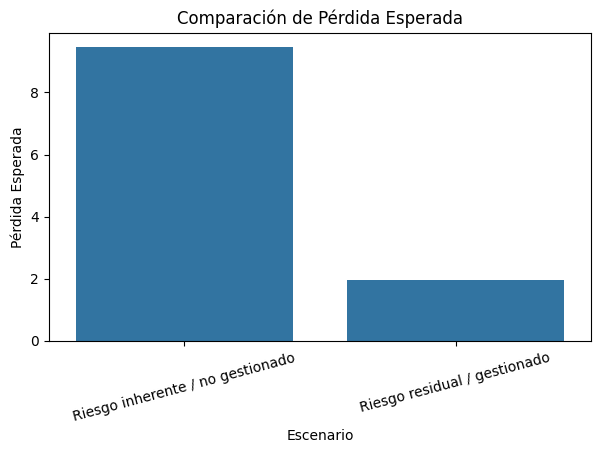

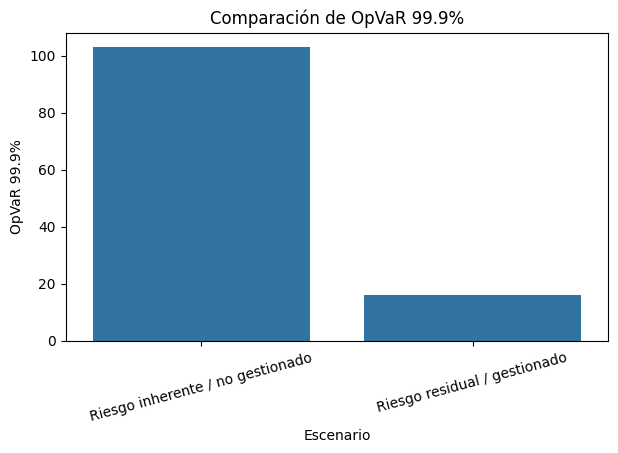

In [16]:
plt.figure(figsize=(7,4))
sns.barplot(data=resumen_riesgo, x='Escenario', y='Pérdida Esperada')
plt.title('Comparación de Pérdida Esperada')
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(7,4))
sns.barplot(data=resumen_riesgo, x='Escenario', y='OpVaR 99.9%')
plt.title('Comparación de OpVaR 99.9%')
plt.xticks(rotation=15)
plt.show()


## 10. Herramienta de auditoría: filtro dinámico por celda

In [17]:
def auditar_celda(nivel_frecuencia, nivel_severidad):
    """
    Filtra los eventos que componen una celda específica de la matriz.
    Los niveles van de 0 a 4:
    0 = Muy bajo, 1 = Bajo, 2 = Medio, 3 = Alto, 4 = Muy alto
    """
    resultado = matriz_df[
        (matriz_df['nivel_f'] == nivel_frecuencia) &
        (matriz_df['nivel_s'] == nivel_severidad)
    ][[
        'fecha', 'freq', 'sev', 'perdida_no_gestionada',
        'nivel_impacto', 'nivel_gestion', 'perdida_gestionada',
        'descripcion_evento'
    ]].sort_values(by='perdida_no_gestionada', ascending=False)

    print(f'Eventos encontrados en la celda frecuencia={nivel_frecuencia}, severidad={nivel_severidad}:', len(resultado))
    return resultado

# Ejemplo: revisar celda de alta frecuencia y alta severidad
auditar_celda(4, 4).head(20)


Eventos encontrados en la celda frecuencia=4, severidad=4: 5


,fecha,freq,sev,perdida_no_gestionada,nivel_impacto,nivel_gestion,perdida_gestionada,descripcion_evento
218,2009-08-07,9,9.1223,82.1007,5,5.0000,16.4201,"Caída total del sistema por más de 24 horas, p..."
202,2009-07-22,7,11.2667,78.8669,5,5.0000,15.7734,"Caída total del sistema por más de 24 horas, p..."
329,2009-11-26,7,10.6269,74.3883,5,5.0000,14.8777,"Caída total del sistema por más de 24 horas, p..."
405,2011-02-25,7,7.3845,51.6915,5,5.0000,10.3383,Degradación severa del rendimiento por más de ...
228,2009-08-17,7,7.2316,50.6212,5,5.0000,10.1242,Degradación severa del rendimiento por más de ...


El filtro permite ver qué eventos específicos están detrás de cada nivel de riesgo, facilitando entender mejor lo que está pasando.

In [18]:
#Filtro interactivo
try:
    import ipywidgets as widgets
    from IPython.display import display

    selector_f = widgets.Dropdown(
        options=[(niveles[i], i) for i in range(5)],
        value=4,
        description='Frecuencia:'
    )
    selector_s = widgets.Dropdown(
        options=[(niveles[i], i) for i in range(5)],
        value=4,
        description='Severidad:'
    )

    salida = widgets.Output()

    def actualizar(change=None):
        with salida:
            salida.clear_output()
            display(auditar_celda(selector_f.value, selector_s.value))

    selector_f.observe(actualizar, names='value')
    selector_s.observe(actualizar, names='value')

    display(selector_f, selector_s, salida)
    actualizar()
except Exception as e:
    print('No se pudo cargar el filtro interactivo. Usa auditar_celda(nivel_frecuencia, nivel_severidad).')
    print(e)


Dropdown(description='Frecuencia:', index=4, options=(('Muy bajo', 0), ('Bajo', 1), ('Medio', 2), ('Alto', 3),…

Dropdown(description='Severidad:', index=4, options=(('Muy bajo', 0), ('Bajo', 1), ('Medio', 2), ('Alto', 3), …

Output()

## 11. Resumen de resultados

In [20]:
print('RESUMEN EJECUTIVO')
print(f'Pérdida esperada no gestionada: {PE_inherente:,.2f} millones')
print(f'Pérdida esperada gestionada: {PE_residual:,.2f} millones')
print(f'Reducción estimada de PE por gestión: {(1 - PE_residual / PE_inherente):.2%}')
print(f'OpVaR 99.9% no gestionado: {OpVaR_inherente:,.2f} millones')
print(f'OpVaR 99.9% gestionado: {OpVaR_residual:,.2f} millones')
print(f'Reducción estimada de OpVaR por gestión: {(1 - OpVaR_residual / OpVaR_inherente):.2%}')


RESUMEN EJECUTIVO
Pérdida esperada no gestionada: 9.45 millones
Pérdida esperada gestionada: 1.96 millones
Reducción estimada de PE por gestión: 79.21%
OpVaR 99.9% no gestionado: 102.90 millones
OpVaR 99.9% gestionado: 15.97 millones
Reducción estimada de OpVaR por gestión: 84.48%


Analisis de resultados

La mayor concentración de eventos se encuentra en niveles de frecuencia media y alta, esto indica que el riesgo está impulsado mas que todo por la recurrencia de fallas más que por eventos independientes.

En cuanto al impacto los valores más altos se observan en niveles de severidad alta y muy alta, donde las pérdidas aumentan significativamente, esto evidencia que estos eventos aunque son menos frecuentes, generan un impacto económico importante.
Al juntar las dos dimensiones, se identifica que las mayores pérdidas estan en combinaciones de frecuencia alta y severidad media–alta, estos son los puntos críticos del riesgo.

Por ultimo en  cuanto a la gestión, se puede ver una reducción significativa del riesgo, donde la pérdida esperada disminuye de 9.45 a 1.96 ( masomenos 79%) y el OpVaR de 102.9 a 15.97 (masomenos 84%), esto demuestra la efectividad de los controles que se implementaron.

Creacion de la pagina web

In [22]:
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns

# Función para convertir gráficos a Base64
def fig_to_base64(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', bbox_inches='tight', dpi=150)
    buffer.seek(0)
    img_base64 = base64.b64encode(buffer.read()).decode('utf-8')
    buffer.close()
    return img_base64


In [24]:
# Matriz de frecuencia
fig1, ax = plt.subplots(figsize=(7,5))
sns.heatmap(MEf, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=niveles, yticklabels=niveles, ax=ax)
ax.set_title('Matriz de Frecuencia')
ax.set_xlabel('Nivel de severidad')
ax.set_ylabel('Nivel de frecuencia')
img_frecuencia = fig_to_base64(fig1)
plt.close(fig1)

# Matriz de severidad promedio
fig2, ax = plt.subplots(figsize=(7,5))
sns.heatmap(MEs, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=niveles, yticklabels=niveles, ax=ax)
ax.set_title('Matriz de Severidad Promedio')
ax.set_xlabel('Nivel de severidad')
ax.set_ylabel('Nivel de frecuencia')
img_severidad = fig_to_base64(fig2)
plt.close(fig2)

# Matriz de pérdidas inherentes
fig3, ax = plt.subplots(figsize=(7,5))
sns.heatmap(MELDA, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=niveles, yticklabels=niveles, ax=ax)
ax.set_title('Matriz de Pérdidas Agregadas - Riesgo Inherente')
ax.set_xlabel('Nivel de severidad')
ax.set_ylabel('Nivel de frecuencia')
img_inherente = fig_to_base64(fig3)
plt.close(fig3)

# Matriz de pérdidas gestionadas / residual
fig4, ax = plt.subplots(figsize=(7,5))
sns.heatmap(MER, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=niveles, yticklabels=niveles, ax=ax)
ax.set_title('Matriz de Pérdidas Gestionadas - Riesgo Residual')
ax.set_xlabel('Nivel de severidad')
ax.set_ylabel('Nivel de frecuencia')
img_residual = fig_to_base64(fig4)
plt.close(fig4)

In [25]:
resumen_html = resumen_riesgo.to_html(index=False, border=0)

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Reto Riesgo Operacional</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 40px;
            background-color: #fafafa;
            color: #333;
        }}
        h1, h2 {{
            color: #222;
        }}
        .card {{
            background: white;
            padding: 25px;
            margin-bottom: 30px;
            border-radius: 12px;
            box-shadow: 0px 2px 8px rgba(0,0,0,0.08);
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin-top: 15px;
        }}
        th, td {{
            border: 1px solid #ddd;
            padding: 10px;
            text-align: center;
        }}
        th {{
            background-color: #f2f2f2;
        }}
        img {{
            max-width: 100%;
            display: block;
            margin: 20px auto;
            border: 1px solid #ddd;
            border-radius: 8px;
        }}
        p {{
            line-height: 1.6;
        }}
    </style>
</head>

<body>

    <h1>Evaluación del Riesgo Operacional en Canales Electrónicos</h1>

    <div class="card">
        <h2>Contexto</h2>
        <p>
        Este análisis evalúa eventos de riesgo tecnológico en canales electrónicos,
        identificando la frecuencia, severidad, pérdidas agregadas y efecto de la gestión
        sobre el riesgo operacional.
        </p>
    </div>

    <div class="card">
        <h2>Matriz de Frecuencia</h2>
        <p>La mayor concentración de eventos se presenta en niveles de frecuencia media y alta.</p>
        <img src="data:image/png;base64,{img_frecuencia}">
    </div>

    <div class="card">
        <h2>Matriz de Severidad</h2>
        <p>Los valores más altos se concentran en niveles de severidad alta y muy alta.</p>
        <img src="data:image/png;base64,{img_severidad}">
    </div>

    <div class="card">
        <h2>Riesgo Inherente</h2>
        <p>
        La matriz de pérdidas agregadas muestra el riesgo antes de aplicar controles.
        Los puntos críticos se concentran en combinaciones de frecuencia alta y severidad media-alta.
        </p>
        <img src="data:image/png;base64,{img_inherente}">
    </div>

    <div class="card">
        <h2>Riesgo Residual</h2>
        <p>
        Después de aplicar gestión, las pérdidas disminuyen significativamente,
        mostrando la efectividad de los controles.
        </p>
        <img src="data:image/png;base64,{img_residual}">
    </div>

    <div class="card">
        <h2>Pérdida Esperada y OpVaR 99.9%</h2>
        {resumen_html}
    </div>

    <div class="card">
        <h2>Análisis de resultados</h2>
        <p>
        El riesgo está concentrado principalmente en eventos frecuentes con impacto medio-alto.
        Sin embargo, al comparar el riesgo inherente con el riesgo residual, se observa que la
        pérdida esperada disminuye de 9.45 a 1.96, aproximadamente un 79%, mientras que el OpVaR
        baja de 102.9 a 15.97, cerca de un 84%.
        </p>
        <p>
        Esto evidencia que la gestión implementada reduce significativamente tanto las pérdidas
        promedio como los escenarios extremos.
        </p>
    </div>

</body>
</html>
"""

In [26]:
with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("Archivo index.html creado correctamente")

Archivo index.html creado correctamente


In [27]:
from google.colab import files
files.download("index.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>